# 0. Install and Import Dependencies

In [1]:
import sys
print(sys.path)
print(sys.executable)
print(sys.version)

['C:\\Users\\firas\\.pyenv\\pyenv-win\\versions\\3.9.13\\python39.zip', 'C:\\Users\\firas\\.pyenv\\pyenv-win\\versions\\3.9.13\\DLLs', 'C:\\Users\\firas\\.pyenv\\pyenv-win\\versions\\3.9.13\\lib', 'C:\\Users\\firas\\.pyenv\\pyenv-win\\versions\\3.9.13', 'C:\\Users\\firas\\OneDrive\\Desktop\\9RAYAAAA\\PFA\\PFA2\\files\\lipnet_env', '', 'C:\\Users\\firas\\OneDrive\\Desktop\\9RAYAAAA\\PFA\\PFA2\\files\\lipnet_env\\lib\\site-packages', 'C:\\Users\\firas\\OneDrive\\Desktop\\9RAYAAAA\\PFA\\PFA2\\files\\lipnet_env\\lib\\site-packages\\win32', 'C:\\Users\\firas\\OneDrive\\Desktop\\9RAYAAAA\\PFA\\PFA2\\files\\lipnet_env\\lib\\site-packages\\win32\\lib', 'C:\\Users\\firas\\OneDrive\\Desktop\\9RAYAAAA\\PFA\\PFA2\\files\\lipnet_env\\lib\\site-packages\\Pythonwin']
C:\Users\firas\OneDrive\Desktop\9RAYAAAA\PFA\PFA2\files\lipnet_env\Scripts\python.exe
3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]


In [1]:
import os
import cv2
import tensorflow as tf
import numpy as np
from typing import List
from matplotlib import pyplot as plt
import imageio
import dlib

In [3]:
#tf.config.list_physical_devices('GPU')

In [2]:
physical_devices = tf.config.list_physical_devices('GPU')
try:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
    pass

# 1. Build Data Loading Functions

In [5]:
#import gdown

In [6]:
"""url = 'https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL'
output = 'data.zip'
gdown.download(url, output, quiet=False)
gdown.extractall('data.zip')"""

"url = 'https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL'\noutput = 'data.zip'\ngdown.download(url, output, quiet=False)\ngdown.extractall('data.zip')"

In [13]:
def load_video(path:str) -> List[float]: 

    cap = cv2.VideoCapture(path)
    frames = []
    for _ in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))): 
        ret, frame = cap.read()
        frame = tf.image.rgb_to_grayscale(frame)
        frames.append(frame[190:236,80:220,:])
    cap.release()
    
    mean = tf.math.reduce_mean(frames)
    std = tf.math.reduce_std(tf.cast(frames, tf.float32))
    return tf.cast((frames - mean), tf.float32) / std

In [11]:
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]

In [12]:
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, oov_token="")
num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True
)

print(
    f"The vocabulary is: {char_to_num.get_vocabulary()} "
    f"(size ={char_to_num.vocabulary_size()})"
)

The vocabulary is: ['', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', "'", '?', '!', '1', '2', '3', '4', '5', '6', '7', '8', '9', ' '] (size =40)


In [10]:
char_to_num.get_vocabulary()

['',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 "'",
 '?',
 '!',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 ' ']

In [11]:
char_to_num(['n','i','c','k'])

<tf.Tensor: shape=(4,), dtype=int64, numpy=array([14,  9,  3, 11], dtype=int64)>

In [12]:
num_to_char([14,  9,  3, 11])

<tf.Tensor: shape=(4,), dtype=string, numpy=array([b'n', b'i', b'c', b'k'], dtype=object)>

In [14]:
def load_alignments(path:str) -> List[str]: 
    with open(path, 'r') as f: 
        lines = f.readlines() 
    tokens = []
    for line in lines:
        line = line.split()
        if line[2] != 'sil': 
            tokens = [*tokens,' ',line[2]]
    return char_to_num(tf.reshape(tf.strings.unicode_split(tokens, input_encoding='UTF-8'), (-1)))[1:]

In [15]:
def load_data(path: str): 
    path = bytes.decode(path.numpy())
    # File name splitting for linux
    #file_name = path.split('/')[-1].split('.')[0]
    # File name splitting for windows
    file_name = path.split('\\')[-1].split('.')[0]
    video_path = os.path.join('data','s1',f'{file_name}.mpg')
    alignment_path = os.path.join('data','alignments','s1',f'{file_name}.align')
    frames = load_video(video_path) 
    alignments = load_alignments(alignment_path)
    
    return frames, alignments

In [12]:
test_path = '.\\data\\s1\\bbal6n.mpg'

In [13]:
tf.convert_to_tensor(test_path).numpy().decode('utf-8').split('\\')[-1].split('.')[0]

'bbal6n'

In [14]:
frames, alignments = load_data(tf.convert_to_tensor(test_path))

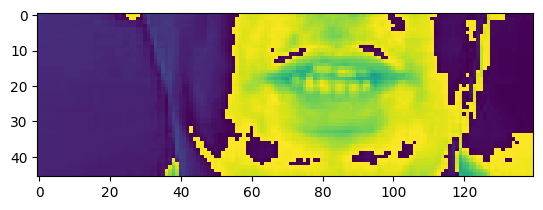

In [17]:
plt.imshow(frames[40])

In [18]:
alignments

<tf.Tensor: shape=(21,), dtype=int64, numpy=
array([ 2,  9, 14, 39,  2, 12, 21,  5, 39,  1, 20, 39, 12, 39, 19,  9, 24,
       39, 14, 15, 23], dtype=int64)>

In [19]:
tf.strings.reduce_join([bytes.decode(x) for x in num_to_char(alignments.numpy()).numpy()])

<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue at l six now'>

In [7]:
def mappable_function(path:str) ->List[str]:
    result = tf.py_function(load_data, [path], (tf.float32, tf.int64))
    return result

# 2. Create Data Pipeline

In [22]:
#from matplotlib import pyplot as plt

In [16]:
data = tf.data.Dataset.list_files('./data/s1/*.mpg')
data = data.shuffle(500, reshuffle_each_iteration=False)
data = data.map(mappable_function)
data = data.padded_batch(2, padded_shapes=([75,None,None,None],[40]))
data = data.prefetch(tf.data.AUTOTUNE)
# Added for split 
train = data.take(450)
test = data.skip(450)

In [24]:
len(test)

50

In [32]:
frames, alignments = data.as_numpy_iterator().next()

In [26]:
len(frames)

2

In [33]:
sample = data.as_numpy_iterator()

In [34]:
val = sample.next(); val[0]

array([[[[[ 1.3853195 ],
          [ 1.3853195 ],
          [ 1.3061583 ],
          ...,
          [ 9.776398  ],
          [ 0.11874167],
          [ 0.07916111]],

         [[ 1.3853195 ],
          [ 1.3853195 ],
          [ 1.3061583 ],
          ...,
          [ 9.815978  ],
          [ 0.        ],
          [ 0.        ]],

         [[ 1.3061583 ],
          [ 1.3061583 ],
          [ 1.3061583 ],
          ...,
          [ 0.03958056],
          [ 0.07916111],
          [ 0.07916111]],

         ...,

         [[ 0.91035277],
          [ 0.91035277],
          [ 0.91035277],
          ...,
          [ 9.9743    ],
          [ 9.934719  ],
          [ 9.934719  ]],

         [[ 0.91035277],
          [ 0.91035277],
          [ 0.91035277],
          ...,
          [ 9.9743    ],
          [ 9.934719  ],
          [ 9.934719  ]],

         [[ 0.91035277],
          [ 0.91035277],
          [ 0.91035277],
          ...,
          [ 9.9743    ],
          [ 9.934719  ],
          

In [29]:
imageio.mimsave('./animation.gif', val[0][0], fps=10)

Lossy conversion from float32 to uint8. Range [0.0, 9.774018287658691]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.774018287658691]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.774018287658691]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.774018287658691]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.774018287658691]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.774018287658691]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.774018287658691]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. R

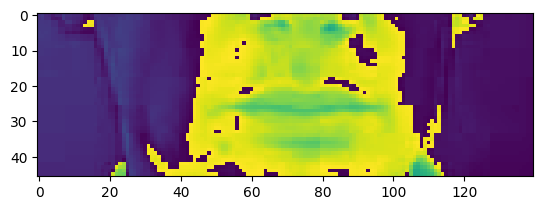

In [30]:
# 0:videos, 0: 1st video out of the batch,  0: return the first frame in the video 
plt.imshow(val[0][0][0])

In [31]:
tf.strings.reduce_join([num_to_char(word) for word in val[1][0]])

<tf.Tensor: shape=(), dtype=string, numpy=b'bin green at t eight now'>

# 3. Design the Deep Neural Network

In [5]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler

In [11]:
data.as_numpy_iterator().next()[0][0].shape

(75, 46, 140, 1)

In [17]:
model = Sequential()
model.add(Conv3D(128, 3, input_shape=(75,46,140,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(Conv3D(256, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(Conv3D(75, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(TimeDistributed(Flatten()))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Dense(char_to_num.vocabulary_size()+1, kernel_initializer='he_normal', activation='softmax'))

In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d (Conv3D)             (None, 75, 46, 140, 128)  3584      
                                                                 
 activation (Activation)     (None, 75, 46, 140, 128)  0         
                                                                 
 max_pooling3d (MaxPooling3D  (None, 75, 23, 70, 128)  0         
 )                                                               
                                                                 
 conv3d_1 (Conv3D)           (None, 75, 23, 70, 256)   884992    
                                                                 
 activation_1 (Activation)   (None, 75, 23, 70, 256)   0         
                                                                 
 max_pooling3d_1 (MaxPooling  (None, 75, 11, 35, 256)  0         
 3D)                                                    

In [30]:
#5*17*75

6375

In [35]:
yhat = model.predict(val[0])

1/1 [==============================] - 5s 5s/step


In [36]:
tf.strings.reduce_join([num_to_char(x) for x in tf.argmax(yhat[0],axis=1)])

<tf.Tensor: shape=(), dtype=string, numpy=b'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaccccc'>

In [37]:
tf.strings.reduce_join([num_to_char(tf.argmax(x)) for x in yhat[0]])

<tf.Tensor: shape=(), dtype=string, numpy=b'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaccccc'>

In [40]:
model.input_shape

(None, 75, 46, 140, 1)

In [41]:
model.output_shape

(None, 75, 41)

# 4. Setup Training Options and Train

In [42]:
## model tr

In [37]:
def scheduler(epoch, lr):
    if epoch < 30:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [38]:
def CTCLoss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

In [39]:
class ProduceExample(tf.keras.callbacks.Callback): 
    def __init__(self, dataset) -> None: 
        self.dataset = dataset.as_numpy_iterator()
    
    def on_epoch_end(self, epoch, logs=None) -> None:
        data = self.dataset.next()
        yhat = self.model.predict(data[0])
        decoded = tf.keras.backend.ctc_decode(yhat, [75,75], greedy=False)[0][0].numpy()
        for x in range(len(yhat)):           
            print('Original:', tf.strings.reduce_join(num_to_char(data[1][x])).numpy().decode('utf-8'))
            print('Prediction:', tf.strings.reduce_join(num_to_char(decoded[x])).numpy().decode('utf-8'))
            print('~'*100)

In [40]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss=CTCLoss)

In [41]:
checkpoint_callback = ModelCheckpoint(os.path.join('models','checkpoint'), monitor='loss', save_weights_only=True) 

In [42]:
schedule_callback = LearningRateScheduler(scheduler)

In [43]:
example_callback = ProduceExample(test)

In [45]:
#model.fit(train, validation_data=test, epochs=100, callbacks=[checkpoint_callback, schedule_callback, example_callback])

# 5. Make a Prediction 

In [46]:
## did it manually no need to run this cell

"""url = 'https://drive.google.com/uc?id=1vWscXs4Vt0a_1IH1-ct2TCgXAZT-N3_Y'
output = 'checkpoints.zip'
gdown.download(url, output, quiet=False)
gdown.extractall('checkpoints.zip', 'models')"""

"url = 'https://drive.google.com/uc?id=1vWscXs4Vt0a_1IH1-ct2TCgXAZT-N3_Y'\noutput = 'checkpoints.zip'\ngdown.download(url, output, quiet=False)\ngdown.extractall('checkpoints.zip', 'models')"

In [44]:
model.load_weights('models/checkpoint')

In [22]:
test_data = test.as_numpy_iterator()

In [23]:
sample = test_data.next()

In [24]:
yhat = model.predict(sample[0])

1/1 [==============================] - 6s 6s/step


In [25]:
print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in sample[1]]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ REAL TEXT


[<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue with m four now'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'lay green by g zero please'>]

In [26]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75,75], greedy=True)[0][0].numpy()

In [27]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PREDICTIONS


[<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue with m four now'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'lay green by g zero please'>]

# Test on a Video

In [45]:
sample = load_data(tf.convert_to_tensor('.\\data\\s1\\swwv9a.mpg'))

In [46]:

print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in [sample[1]]]


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ REAL TEXT


[<tf.Tensor: shape=(), dtype=string, numpy=b'set white with sp v nine again'>]

In [47]:
yhat = model.predict(tf.expand_dims(sample[0], axis=0))
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75], greedy=True)[0][0].numpy()
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

1/1 [==============================] - 3s 3s/step
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PREDICTIONS


[<tf.Tensor: shape=(), dtype=string, numpy=b'set white with sp s nine again'>]

In [28]:
"""def load_test_video(path:str) -> List[float]: 

    cap = cv2.VideoCapture(path)
    frames = []
    for _ in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))): 
        ret, frame = cap.read()
        frame = tf.image.rgb_to_grayscale(frame)
        frames.append(frame[200:350,250:475,:])
    cap.release()
    
    mean = tf.math.reduce_mean(frames)
    std = tf.math.reduce_std(tf.cast(frames, tf.float32))
    return tf.cast((frames - mean), tf.float32) / std"""

'def load_test_video(path:str) -> List[float]: \n\n    cap = cv2.VideoCapture(path)\n    frames = []\n    for _ in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))): \n        ret, frame = cap.read()\n        frame = tf.image.rgb_to_grayscale(frame)\n        frames.append(frame[200:350,250:475,:])\n    cap.release()\n    \n    mean = tf.math.reduce_mean(frames)\n    std = tf.math.reduce_std(tf.cast(frames, tf.float32))\n    return tf.cast((frames - mean), tf.float32) / std'

In [29]:
"""def load_test_data(path: str): 
    path = bytes.decode(path.numpy())
    # File name splitting for linux
    #file_name = path.split('/')[-1].split('.')[0]
    # File name splitting for windows
    file_name = path.split('\\')[-1].split('.')[0]
    video_path = os.path.join('RL tests','vids',f'{file_name}.mpg')
    alignment_path = os.path.join('RL tests','alignments',f'{file_name}.align')
    frames = load_test_video(video_path) 
    alignments = load_alignments(alignment_path)
    
    return frames, alignments"""

"def load_test_data(path: str): \n    path = bytes.decode(path.numpy())\n    # File name splitting for linux\n    #file_name = path.split('/')[-1].split('.')[0]\n    # File name splitting for windows\n    file_name = path.split('\\')[-1].split('.')[0]\n    video_path = os.path.join('RL tests','vids',f'{file_name}.mpg')\n    alignment_path = os.path.join('RL tests','alignments',f'{file_name}.align')\n    frames = load_test_video(video_path) \n    alignments = load_alignments(alignment_path)\n    \n    return frames, alignments"

In [48]:
def load_custom_video(video_path : str, target_frames=75, target_h=46, target_w=140):
    """
    Loads a custom video, detects the mouth region per frame using dlib,
    crops + resizes to (46, 140), converts to grayscale, and pads/trims
    to exactly 75 frames.
    Returns an array of shape (75, 46, 140, 1) normalized to [0, 1].
    """

    # --- 1. Load dlib's face detector and landmark predictor ---
    detector = dlib.get_frontal_face_detector()
    predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

    # Landmark indices for the mouth (points 48–67 in the 68-point model)
    MOUTH_POINTS = list(range(48, 68))

    # --- 2. Open the video file ---
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to grayscale for dlib detection
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = detector(gray)

        if len(faces) == 0:
            # No face found in this frame — use a blank frame as fallback
            mouth_crop = np.zeros((target_h, target_w), dtype=np.uint8)
        else:
            # Take the first (largest) face
            face = faces[0]
            landmarks = predictor(gray, face)

            # Get the (x, y) coordinates of all mouth landmarks
            mouth_coords = np.array([
                [landmarks.part(n).x, landmarks.part(n).y]
                for n in MOUTH_POINTS
            ])

            # Compute a bounding box around the mouth with some padding
            x_min = max(mouth_coords[:, 0].min() - 10, 0)
            x_max = min(mouth_coords[:, 0].max() + 10, frame.shape[1])
            y_min = max(mouth_coords[:, 1].min() - 10, 0)
            y_max = min(mouth_coords[:, 1].max() + 10, frame.shape[0])

            # Crop to mouth region from grayscale frame
            mouth_crop = gray[y_min:y_max, x_min:x_max]

        # Resize to exactly (target_w, target_h) — note: cv2 takes (width, height)
        mouth_resized = cv2.resize(mouth_crop, (target_w, target_h))

        frames.append(mouth_resized)

    cap.release()

    # --- 3. Fix the frame count to exactly 75 ---
    total = len(frames)

    if total == 0:
        raise ValueError("No frames could be read from the video.")

    if total < target_frames:
        # Pad by repeating the last frame
        pad = [frames[-1]] * (target_frames - total)
        frames = frames + pad
    else:
        # Uniformly sample 75 frames across the video
        indices = np.linspace(0, total - 1, target_frames, dtype=int)
        frames = [frames[i] for i in indices]

    # --- 4. Stack into numpy array ---
    # Shape: (75, 46, 140)
    video_array = np.stack(frames, axis=0)

    # --- 5. Add channel dim → (75, 46, 140, 1) ---
    video_array = np.expand_dims(video_array, axis=-1)

    # --- 6. Normalize to [0, 1] (same as GRID training data) ---
    video_array = video_array / 255.0

    return video_array.astype(np.float32)

In [71]:
# Replace this path with the actual path to your recorded video
MY_VIDEO_PATH = r"C:\users\firas\onedrive\desktop\9rayaaaa\pfa\pfa2\files\RL tests\vids\ye seifalah le trabhek again.mpg"   # or .avi, .mov, etc.

sample_fixed = load_custom_video(MY_VIDEO_PATH)

print("Shape:", sample_fixed.shape)          # Should print: (75, 46, 140, 1)
print("Min/Max:", sample_fixed.min(), sample_fixed.max())  # Should be ~0.0 to ~1.0

Shape: (75, 46, 140, 1)
Min/Max: 0.0 0.0


In [72]:
input_data = np.expand_dims(sample_fixed, axis=0)   # shape: (1, 75, 46, 140, 1)
print("input_data shape:", input_data.shape)         # Must be (1, 75, 46, 140, 1)

yhat = model.predict(input_data)

input_data shape: (1, 75, 46, 140, 1)
1/1 [==============================] - 2s 2s/step


In [75]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75], greedy=True)[0][0].numpy()

In [76]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PREDICTIONS


[<tf.Tensor: shape=(), dtype=string, numpy=b't oea he aiw fo '>]

Total frames in video: 105


C:\Users\firas\AppData\Local\Temp\ipykernel_17008\1793194303.py:85: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout()
C:\Users\firas\AppData\Local\Temp\ipykernel_17008\1793194303.py:85: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from current font.
  plt.tight_layout()
C:\Users\firas\AppData\Local\Temp\ipykernel_17008\1793194303.py:85: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()


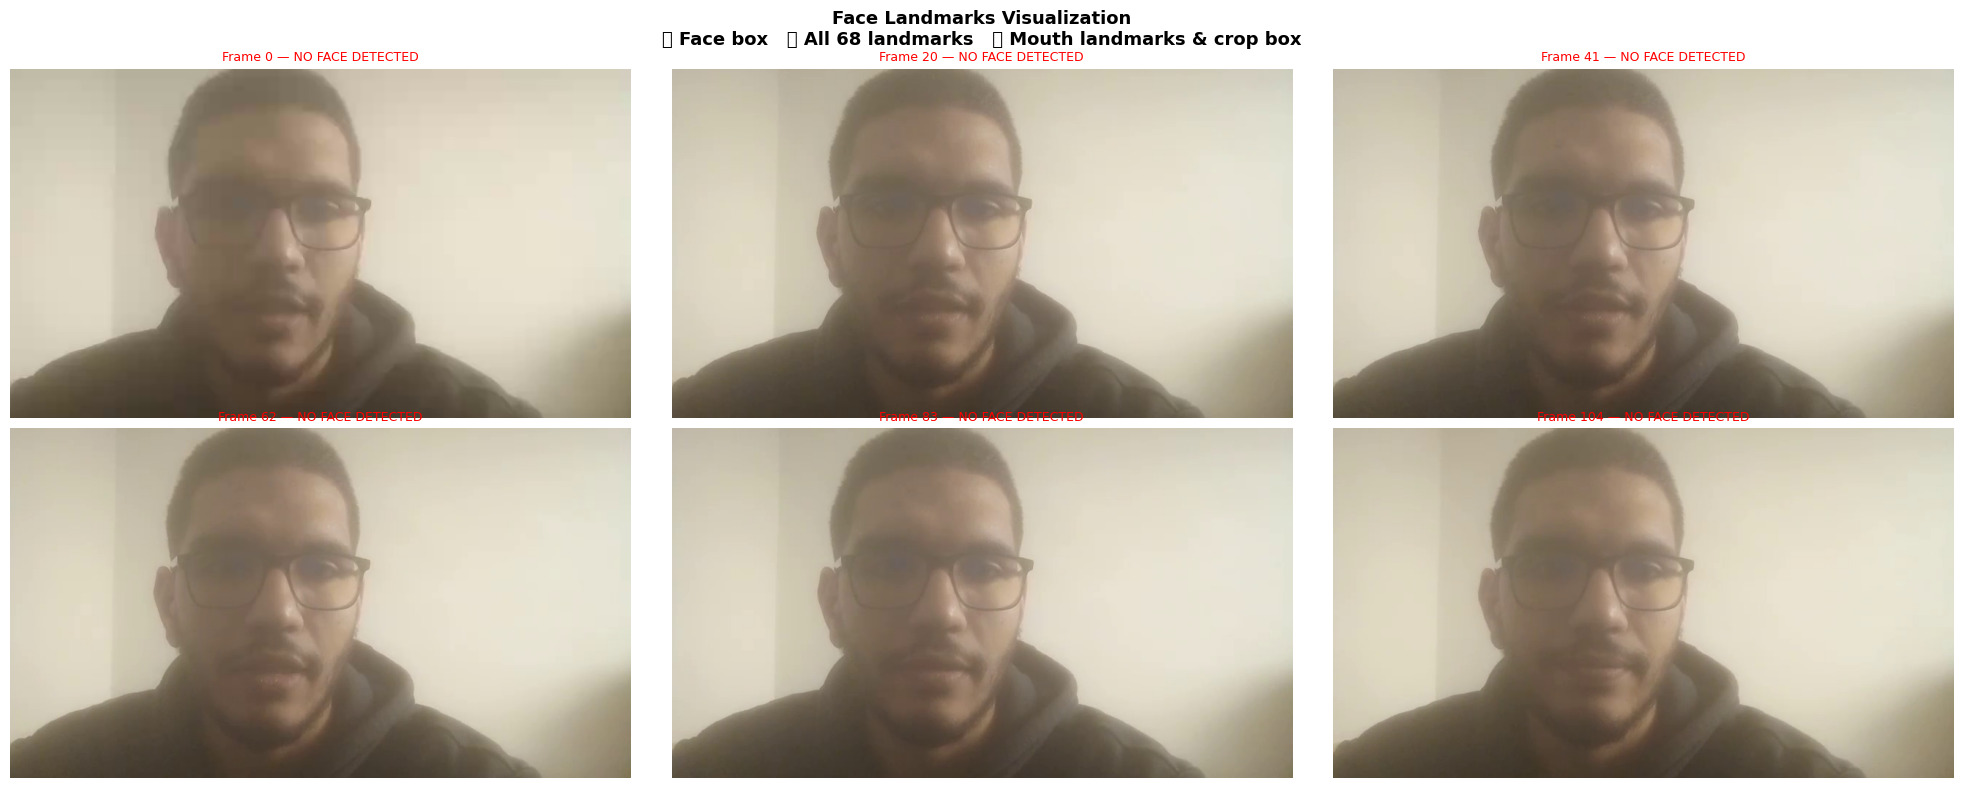

In [77]:
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_landmarks(video_path, num_frames_to_show=6):
    """
    Displays a grid of sampled frames from your video with:
    - Face bounding box (green rectangle)
    - All 68 facial landmarks (blue dots)
    - Mouth landmarks specifically highlighted (red dots)
    - Mouth bounding box (red rectangle)
    """
    detector = dlib.get_frontal_face_detector()
    predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
    MOUTH_POINTS = list(range(48, 68))

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames in video: {total_frames}")

    # Sample evenly spaced frame indices to display
    sample_indices = np.linspace(0, total_frames - 1, num_frames_to_show, dtype=int)

    fig, axes = plt.subplots(2, num_frames_to_show // 2, figsize=(20, 8))
    axes = axes.flatten()

    for plot_idx, frame_idx in enumerate(sample_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            continue

        # Convert BGR → RGB for matplotlib display
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        ax = axes[plot_idx]
        ax.imshow(frame_rgb)
        ax.set_title(f"Frame {frame_idx}", fontsize=10)
        ax.axis('off')

        faces = detector(gray)

        if len(faces) == 0:
            ax.set_title(f"Frame {frame_idx} — NO FACE DETECTED", color='red', fontsize=9)
            continue

        face = faces[0]
        landmarks = predictor(gray, face)

        # --- Draw face bounding box ---
        face_rect = patches.Rectangle(
            (face.left(), face.top()),
            face.width(), face.height(),
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(face_rect)

        # --- Draw all 68 landmarks (blue) ---
        all_coords = np.array([[landmarks.part(n).x, landmarks.part(n).y] for n in range(68)])
        ax.scatter(all_coords[:, 0], all_coords[:, 1], s=8, c='dodgerblue', zorder=5)

        # --- Draw mouth landmarks (red, larger) ---
        mouth_coords = np.array([[landmarks.part(n).x, landmarks.part(n).y] for n in MOUTH_POINTS])
        ax.scatter(mouth_coords[:, 0], mouth_coords[:, 1], s=20, c='red', zorder=6)

        # --- Draw mouth bounding box (red) ---
        x_min = mouth_coords[:, 0].min() - 10
        x_max = mouth_coords[:, 0].max() + 10
        y_min = mouth_coords[:, 1].min() - 10
        y_max = mouth_coords[:, 1].max() + 10

        mouth_rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min, y_max - y_min,
            linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
        )
        ax.add_patch(mouth_rect)

    cap.release()
    plt.suptitle("Face Landmarks Visualization\n🟢 Face box   🔵 All 68 landmarks   🔴 Mouth landmarks & crop box",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# --- Run it ---
MY_VIDEO_PATH = r"C:\users\firas\onedrive\desktop\9rayaaaa\pfa\pfa2\files\RL tests\vids\ye seifalah le trabhek again.mpg"
visualize_landmarks(MY_VIDEO_PATH, num_frames_to_show=6)

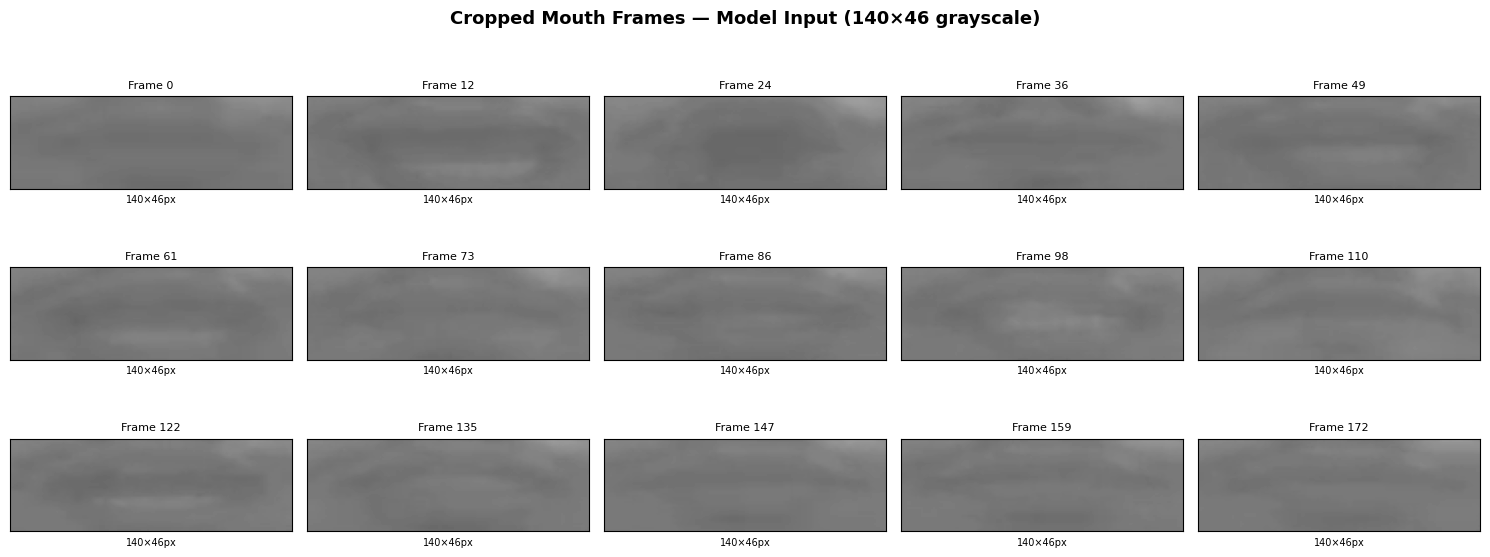


✅ Showing 15 sampled frames out of 173 total.
   Each crop is exactly 140×46 px grayscale — matching model input.


In [51]:
def visualize_mouth_crops(video_path, num_frames_to_show=15, target_h=46, target_w=140):
    """
    Shows the actual cropped + resized mouth frames that get fed into the model.
    Each frame is (46, 140) grayscale — exactly what the model receives.
    """
    detector = dlib.get_frontal_face_detector()
    predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
    MOUTH_POINTS = list(range(48, 68))

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    sample_indices = np.linspace(0, total_frames - 1, num_frames_to_show, dtype=int)

    crops = []
    labels = []

    for frame_idx in sample_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = detector(gray)

        if len(faces) == 0:
            mouth_resized = np.zeros((target_h, target_w), dtype=np.uint8)
            labels.append(f"F{frame_idx}\n(no face)")
        else:
            face = faces[0]
            landmarks = predictor(gray, face)
            mouth_coords = np.array([
                [landmarks.part(n).x, landmarks.part(n).y]
                for n in MOUTH_POINTS
            ])
            x_min = max(mouth_coords[:, 0].min() - 10, 0)
            x_max = min(mouth_coords[:, 0].max() + 10, frame.shape[1])
            y_min = max(mouth_coords[:, 1].min() - 10, 0)
            y_max = min(mouth_coords[:, 1].max() + 10, frame.shape[0])

            mouth_crop = gray[y_min:y_max, x_min:x_max]
            mouth_resized = cv2.resize(mouth_crop, (target_w, target_h))
            labels.append(f"Frame {frame_idx}")

        crops.append(mouth_resized)

    cap.release()

    # --- Plot all crops in a grid ---
    cols = 5
    rows = (len(crops) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2))
    axes = axes.flatten()

    for i, (crop, label) in enumerate(zip(crops, labels)):
        axes[i].imshow(crop, cmap='gray', vmin=0, vmax=255)
        axes[i].set_title(label, fontsize=8)
        axes[i].set_xlabel(f"{crop.shape[1]}×{crop.shape[0]}px", fontsize=7)
        axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Hide unused subplots
    for j in range(len(crops), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"Cropped Mouth Frames — Model Input ({target_w}×{target_h} grayscale)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n✅ Showing {len(crops)} sampled frames out of {total_frames} total.")
    print(f"   Each crop is exactly {target_w}×{target_h} px grayscale — matching model input.")


# --- Run it ---
visualize_mouth_crops(MY_VIDEO_PATH, num_frames_to_show=15)

In [70]:
from tensorflow.keras.backend import ctc_decode

# yhat shape is (1, time_steps, vocab_size)
decoded = ctc_decode(yhat, input_length=[75], greedy=True)[0][0].numpy()

# Convert integer tokens back to characters using the char_to_num mapping
# (this part comes directly from Nick's notebook — num_to_char is defined there)
print([tf.strings.reduce_join([num_to_char(word) for word in sentence]).numpy().decode('utf-8') for sentence in decoded])

['plet eith frue aiy h e sow']


In [38]:
"""test_path = '.\\RL tests\\vids\\hello my name is firas.mpg'
tf.convert_to_tensor(test_path).numpy().decode('utf-8').split('\\')[-1].split('.')[0]
frames, alignments = load_custom_video(tf.convert_to_tensor(test_path))
plt.imshow(frames[10])"""

"test_path = '.\\RL tests\\vids\\hello my name is firas.mpg'\ntf.convert_to_tensor(test_path).numpy().decode('utf-8').split('\\')[-1].split('.')[0]\nframes, alignments = load_custom_video(tf.convert_to_tensor(test_path))\nplt.imshow(frames[10])"

In [47]:
"""
sample = load_test_data(tf.convert_to_tensor('.\\RL tests\\vids\\hello my name is firas.mpg'))
"""

"\nsample = load_test_data(tf.convert_to_tensor('.\\RL tests\\vids\\hello my name is firas.mpg'))\n"

In [46]:
"""
# Convert tensor to numpy
video_np = sample[0].numpy() if hasattr(sample[0], 'numpy') else np.array(sample[0])
total_frames = video_np.shape[0]
indices = np.linspace(0, total_frames-1, 75, dtype=int)
sample_fixed = video_np[indices]

print("Fixed shape:", sample_fixed.shape)          # (75, 46, 140, 1)
print("Input batch shape:", input_data.shape)      # (1, 75, 46, 140, 1)
"""

'\n# Convert tensor to numpy\nvideo_np = sample[0].numpy() if hasattr(sample[0], \'numpy\') else np.array(sample[0])\ntotal_frames = video_np.shape[0]\nindices = np.linspace(0, total_frames-1, 75, dtype=int)\nsample_fixed = video_np[indices]\n\nprint("Fixed shape:", sample_fixed.shape)          # (75, 46, 140, 1)\nprint("Input batch shape:", input_data.shape)      # (1, 75, 46, 140, 1)\n'

In [44]:
"""
# Print detailed model input shape
print("Model input shape:", model.input_shape)
# Also check the first layer's expected shape
print("First layer input shape:", model.layers[0].input_shape)
"""

'\n# Print detailed model input shape\nprint("Model input shape:", model.input_shape)\n# Also check the first layer\'s expected shape\nprint("First layer input shape:", model.layers[0].input_shape)\n'

In [43]:
"""
print("sample_fixed shape:", sample_fixed.shape)
print("sample_fixed dtype:", sample_fixed.dtype)
print("Total elements:", sample_fixed.size)
print("======================================================================")
input_data = np.expand_dims(sample_fixed, axis=0)
print("input_data shape:", input_data.shape)  # should be (1, 75, 46, 140, 1)
print("input_data size:", input_data.size)    # should be 483000
"""

'\nprint("sample_fixed shape:", sample_fixed.shape)\nprint("sample_fixed dtype:", sample_fixed.dtype)\nprint("Total elements:", sample_fixed.size)\nprint("======================================================================")\ninput_data = np.expand_dims(sample_fixed, axis=0)\nprint("input_data shape:", input_data.shape)  # should be (1, 75, 46, 140, 1)\nprint("input_data size:", input_data.size)    # should be 483000\n'

In [42]:
#input_data = np.expand_dims(sample_fixed, axis=0)   # shape (1, 75, 46, 140, 1)
#yhat = model.predict(input_data)
"""yhat = model.predict(tf.expand_dims(sample[0], axis=0))"""

'yhat = model.predict(tf.expand_dims(sample[0], axis=0))'